# Japanese number-plate exploration

This notebook re-derives the three findings written up in the project [README](../README.md) directly from the cleaned data in `../data/clean/`. The point is to show the work, not just the conclusions:

1. **Hiragana exclusion taxonomy.** Of the 46 gojūon, 6 are excluded from plates — and the exclusions group into three different *kinds* of design problem.
2. **Policy-burst wave pattern.** Regional plates roll out in discrete government-issued waves, not continuously.
3. **Cross-prefecture chimei.** Most place names map 1-to-1 to a regional office, but a handful deliberately span two.

Live dashboard: <https://sting41b.github.io/jp-number-plate-dsproject/dashboard/>.

All cells read from `../data/clean/*.json`, which is regenerated by `scripts/02_clean_and_merge.py`. Re-run the pipeline if the underlying data changes; the notebook stays in sync.

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager

# Pick the first Japanese-capable font that's actually installed. Without
# this, Japanese labels render as tofu rectangles. Order is Windows first,
# then macOS, then a Noto fallback for Linux.
PREFERRED_JP_FONTS = ["Yu Gothic", "Meiryo", "MS Gothic", "Hiragino Sans", "Noto Sans CJK JP"]
available = {f.name for f in font_manager.fontManager.ttflist}
for f in PREFERRED_JP_FONTS:
    if f in available:
        plt.rcParams["font.family"] = f
        print(f"Using Japanese font: {f}")
        break
else:
    print("No Japanese font found; CJK labels may render as tofu.")

plt.rcParams["axes.unicode_minus"] = False

CLEAN = Path("../data/clean")

def load(name):
    with open(CLEAN / name, encoding="utf-8") as f:
        return json.load(f)

chimei_df = pd.DataFrame(load("chimei.json"))
hiragana = load("hiragana.json")
hira_df = pd.DataFrame(hiragana["characters"])
gotochi = load("gotochi.json")
gotochi_df = pd.DataFrame(gotochi["plates"])
gotochi_df["issue_date"] = pd.to_datetime(gotochi_df["issue_date"])
summary = load("summary.json")

print("chimei  :", chimei_df.shape, list(chimei_df.columns))
print("hiragana:", hira_df.shape, list(hira_df.columns))
print("gotochi :", gotochi_df.shape, list(gotochi_df.columns))
print("summary :", summary)

Using Japanese font: Yu Gothic
chimei  : (138, 5) ['chimei', 'office', 'prefecture', 'notes', 'is_gotochi']
hiragana: (46, 5) ['kana', 'romaji', 'status', 'category', 'exclusion_reason']
gotochi : (119, 9) ['name', 'name_en', 'prefecture', 'region', 'wave', 'issue_date', 'base_chimei', 'notes', 'cumulative']
summary : {'total_chimei': 138, 'total_gotochi': 119, 'hiragana_used': 40, 'hiragana_excluded': 6, 'bunrui_ranges': 9, 'data_sources': [{'name': 'Wikipedia — 日本のナンバープレート一覧', 'url': 'https://ja.wikipedia.org/wiki/日本のナンバープレート一覧', 'dataset': 'chimei'}, {'name': '大阪自家用自動車協会 — 分類番号解説', 'url': 'https://daijiren.or.jp/number/', 'dataset': 'bunrui_bangou'}, {'name': '国土交通省 — ご当地ナンバープレス', 'url': 'https://www.mlit.go.jp/', 'dataset': 'gotochi'}]}


Four datasets, all hand-curated or scraped, all small. The dataset volume isn't the point — the structure is. Quick sanity dump on what's actually in `chimei_df`:

In [2]:
chimei_df.head(8)

,chimei,office,prefecture,notes,is_gotochi
0,札幌,札幌運輸支局,北海道,None,False
1,函館,函館運輸支局,北海道,None,False
2,旭川,旭川運輸支局,北海道,None,False
3,室蘭,室蘭運輸支局,北海道,None,False
4,苫小牧,室蘭運輸支局,北海道,None,False
5,釧路,釧路運輸支局,北海道,None,False
6,知床,釧路運輸支局,北海道,None,False
7,帯広,帯広運輸支局,北海道,None,False


## Finding 1 — Hiragana exclusions group into three kinds of failure

The hiragana table has a `category` column on each row. For excluded characters this records *why* the character was disallowed. For used characters it's a placeholder (`standard`). Splitting the excluded set by category makes the design intent visible:

In [3]:
excluded = hira_df[hira_df["status"] == "excluded"]
excluded[["kana", "romaji", "category", "exclusion_reason"]]

,kana,romaji,category,exclusion_reason
4,お,o,visual,「あ」との字形混同リスク
19,と,to,visual,「う」との字形混同リスク（手書きで紛らわしい）
24,の,no,semantic,「〜の」と読めるため所有格と誤読される可能性。外交用途にも予約済み
28,へ,he,visual,カタカナ「へ」と字形が同一で判読不能
44,を,wo,semantic,助詞・目的格として読まれるため不採用。事業用（緑ナンバー）専用に一部割当
45,ん,n,phonetic,単独で音節を持たず、前後の音を変化させるため判読・発音困難


In [4]:
cat_counts = excluded["category"].value_counts()
cat_counts

category
visual      3
semantic    2
phonetic    1
Name: count, dtype: int64

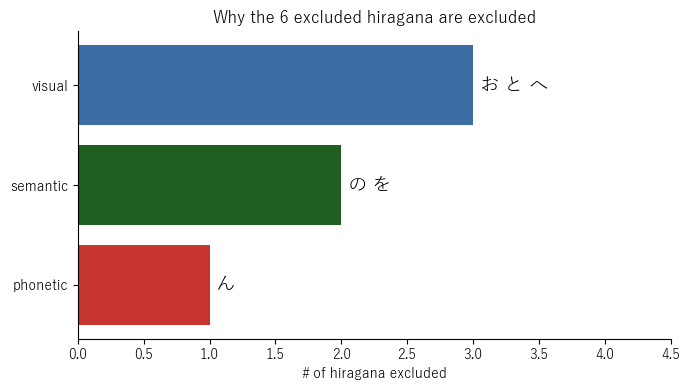

In [5]:
# Bar chart of exclusion categories with the actual kana annotated on top of
# each bar — the chart is small enough that showing the characters costs
# nothing and adds a lot of meaning.
fig, ax = plt.subplots(figsize=(7, 4))
examples_by_cat = excluded.groupby("category")["kana"].apply(lambda s: " ".join(s)).to_dict()
ordered = cat_counts.sort_values()
bars = ax.barh(ordered.index, ordered.values, color=["#c7352f", "#1e5e1e", "#3a6ea5"])
for bar, cat in zip(bars, ordered.index):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        examples_by_cat[cat],
        va="center",
        fontsize=14,
    )
ax.set_xlim(0, ordered.max() + 1.5)
ax.set_xlabel("# of hiragana excluded")
ax.set_title("Why the 6 excluded hiragana are excluded")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Reading the chart:

- **Visual (字形, 3 chars):** `お`, `と`, `へ` — confusable with another character in the typeface used on plates. `お` reads as `あ`, `と` reads as `う`, `へ` reads as the katakana へ.
- **Semantic (語義, 2 chars):** `の`, `を` — these are grammatical particles in Japanese. A plate `…の…` would parse as a possessive phrase rather than an identifier.
- **Phonetic (音韻, 1 char):** `ん` — a moraic nasal that has no standalone syllable; the realised sound depends on what follows. As a single-character identifier it would be ambiguous.

Three different *kinds* of design problem in a 6-character exclusion list. That's the finding.

## Finding 2 — Regional plates roll out in policy bursts, not gradually

The ご当地ナンバー scheme was introduced in 2006. There are 119 plates issued so far. Naively you'd expect a roughly continuous trickle as cities apply. The actual data:

In [6]:
wave_starts = (
    gotochi_df.groupby("wave")
    .agg(start_date=("issue_date", "min"), count=("name", "count"))
    .reset_index()
    .sort_values("start_date")
)
wave_starts["gap_from_prev_yrs"] = (
    wave_starts["start_date"].diff().dt.days / 365.25
).round(1)
wave_starts

,wave,start_date,count,gap_from_prev_yrs
0,1,2006-10-10,29,NaN
1,2,2014-11-17,53,8.1
2,3,2019-05-13,37,4.5


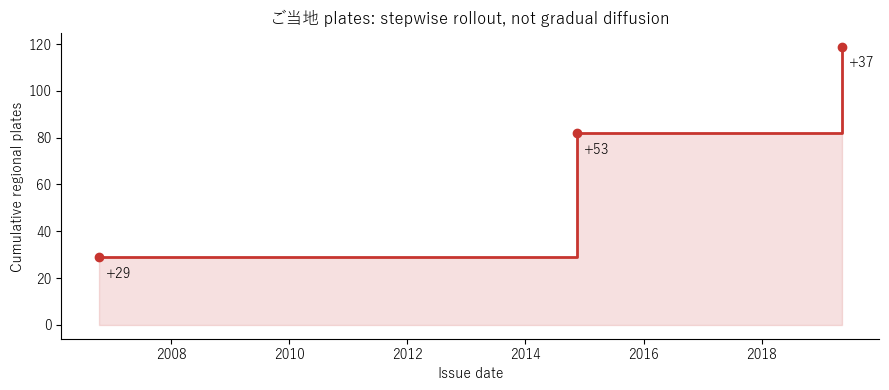

In [7]:
# Stepped cumulative chart. The flat plateaus between the steps are the
# finding: nothing happens for years, then a wave drops dozens of new
# plates in a single day.
by_date = gotochi_df.groupby("issue_date").size().sort_index()
cumulative = by_date.cumsum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.step(cumulative.index, cumulative.values, where="post", color="#c7352f", linewidth=2)
ax.fill_between(cumulative.index, cumulative.values, step="post", alpha=0.15, color="#c7352f")
ax.scatter(cumulative.index, cumulative.values, color="#c7352f", zorder=3)
for d, n in zip(wave_starts["start_date"], wave_starts["count"]):
    ax.annotate(
        f"+{n}",
        xy=(d, cumulative.loc[d]),
        xytext=(5, -15),
        textcoords="offset points",
        fontsize=10,
    )
ax.set_xlabel("Issue date")
ax.set_ylabel("Cumulative regional plates")
ax.set_title("ご当地 plates: stepwise rollout, not gradual diffusion")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Three discrete waves, each landing on a single day:

- **Wave 1 (2006-10-10):** 29 plates.
- **Wave 2 (2014-11-17):** 53 plates — eight years after Wave 1.
- **Wave 3 (2019-05-13):** 37 plates — five years after Wave 2.

MLIT (Ministry of Land, Infrastructure, Transport and Tourism) only opens applications for the scheme periodically. So the cumulative curve is a staircase, not a slope — the rollout is a *policy* artefact rather than a market artefact.

## Finding 3 — A few chimei deliberately cross prefecture lines

Most place names on plates map 1-to-1 to a single 運輸支局 (regional transport office). The exceptions are interesting:

In [8]:
by_chimei = chimei_df.groupby("chimei")["office"].nunique()
cross_office_names = by_chimei[by_chimei > 1].index.tolist()
chimei_df[chimei_df["chimei"].isin(cross_office_names)][["chimei", "office", "prefecture"]]

,chimei,office,prefecture
6,知床,釧路運輸支局,北海道
9,知床,北見運輸支局,北海道
67,富士山,山梨運輸支局,山梨県
84,富士山,静岡運輸支局,静岡県


**富士山** is issued by both **山梨運輸支局** and **静岡運輸支局** — Mt. Fuji straddles both prefectures, and the plate name follows the mountain rather than the administrative line.

**知床** is issued by both **釧路運輸支局** and **北見運輸支局** — the Shiretoko UNESCO World Heritage site sits at the edge of both Hokkaidō sub-regions.

Both cases are deliberate: the plate name follows a geographic / cultural identity, not the bureaucratic boundary. This is why `data/clean/chimei.json` uses `(chimei, office)` as the conceptual compound key — `chimei` alone isn't unique.

### Honesty footnote: the *other* duplicates

While we're talking about uniqueness — `(chimei, office)` isn't unique either. A `value_counts()` finds two more cases that are *not* the cross-prefecture story above:

In [9]:
pair_counts = (
    chimei_df.groupby(["chimei", "office"]).size().reset_index(name="rows").sort_values("rows", ascending=False)
)
pair_counts[pair_counts["rows"] > 1]

,chimei,office,rows
84,沖縄,沖縄総合事務局運輸部,3
123,長崎,長崎運輸支局,2


`沖縄` appears 3× under a single office (`沖縄総合事務局運輸部`); `長崎` appears 2× under `長崎運輸支局`. These aren't cross-office cases — they're the *same* office, *same* place name. The Wikipedia source table disambiguates them with a column called `地名表示の番号` (display-number sequence within an office), which the current pipeline does not carry through to the cleaned JSON.

Pragmatic implication: "138 chimei rows" is not the same as "138 distinct chimei." If a downstream task needs distinct identifiers, either (a) carry `地名表示の番号` through the pipeline, or (b) treat the row index as the identifier. The pytest suite (`tests/test_clean_data.py`) pins the current dupe counts so any silent change in dedup logic fails loudly.

## Closing

Three findings, each derived from a small dataframe and one chart:

1. **Hiragana exclusions are typed by failure mode** (visual / semantic / phonetic), not just an opaque blocklist.
2. **The ご当地 scheme is a staircase**, not a curve — rollouts come in MLIT-controlled bursts.
3. **`chimei` keys aren't unique**, and the reasons are interesting (geographic for 富士山/知床, administrative for 沖縄/長崎).

What I'd want more data on: the failed applications. The 119 plates we have are the ones that *succeeded* — the conditional probability story ("given a city applied, what predicts approval?") needs the rejected applications, which I haven't found a public source for. That's the natural next data-collection step.

All three findings are also surfaced live on the dashboard: <https://sting41b.github.io/jp-number-plate-dsproject/dashboard/>.